### Machine Learning Integration: K-Means Clustering and PCA Visualization

We will use the K-Means algorithm to group penguins into clusters based on their physical characteristics. Then, we will use Principal Component Analysis (PCA) to reduce the dimensionality of the data and visualize these clusters on a 2D plot.

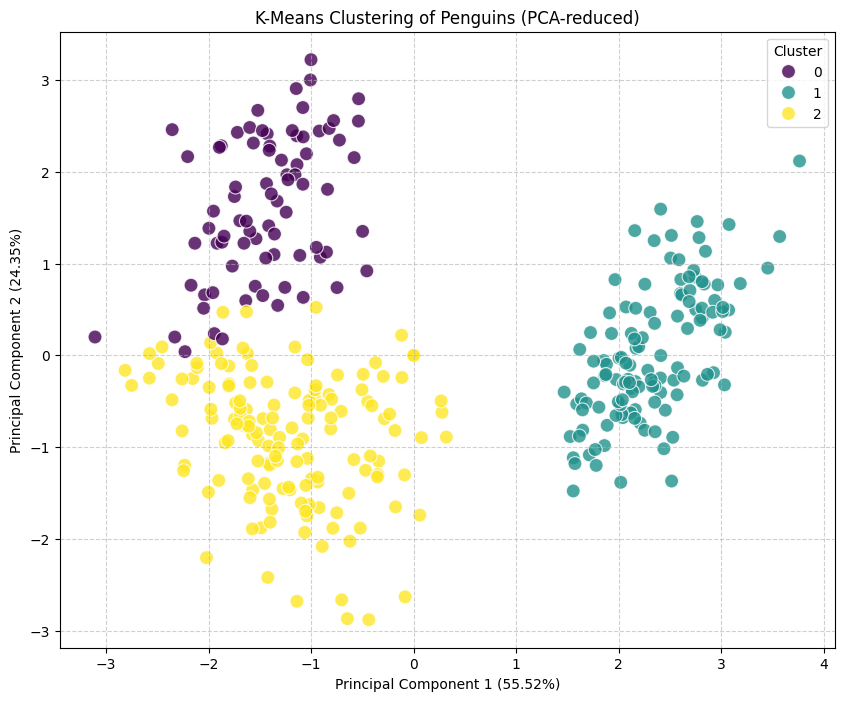

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed data
df_ml = pd.read_csv('data/penguins_preprocessed.csv')

# Select numerical features for clustering
# Exclude 'studyName', 'Sample Number', 'Region', 'Island', 'Stage', 'Clutch Completion', 'Date Egg', 'Sex', 'Individual ID'
features = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)']

X = df_ml[features].copy()

# Handle any remaining NaN values by imputation (e.g., mean imputation) just in case
X.fillna(X.mean(), inplace=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering (let's assume 3 clusters, similar to the number of species)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_ml['Cluster'] = kmeans.fit_predict(X_scaled)

# Perform PCA for dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to the DataFrame for plotting
df_ml['PCA1'] = X_pca[:, 0]
df_ml['PCA2'] = X_pca[:, 1]

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=df_ml,
    s=100, # size of points
    alpha=0.8 # transparency
)
plt.title('K-Means Clustering of Penguins (PCA-reduced)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

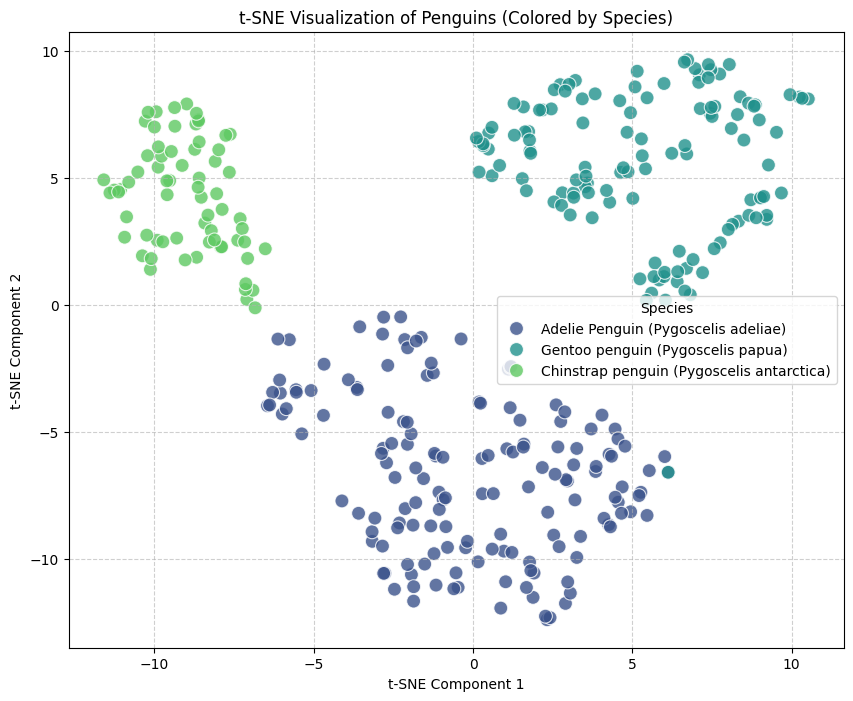

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for t-SNE
# Use the same scaled features that were used for K-Means and PCA
X_scaled_tsne = X_scaled # X_scaled already contains all features used for clustering

# Apply t-SNE
# perplexity is a critical parameter, usually between 5 and 50
# max_iter is the number of iterations for the optimization
t_sne = TSNE(n_components=2, perplexity=30, max_iter=300, random_state=42, learning_rate='auto', init='random')
X_tsne = t_sne.fit_transform(X_scaled_tsne)

# Add t-SNE components to the DataFrame for plotting
df_ml['TSNE1'] = X_tsne[:, 0]
df_ml['TSNE2'] = X_tsne[:, 1]

# Visualize the t-SNE results, colored by actual species
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Species',
    palette='viridis',
    data=df_ml,
    s=100, # size of points
    alpha=0.8 # transparency
)
plt.title('t-SNE Visualization of Penguins (Colored by Species)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Model Accuracy: 0.98

Classification Report:
                                           precision    recall  f1-score   support

      Adelie Penguin (Pygoscelis adeliae)       0.96      1.00      0.98        46
Chinstrap penguin (Pygoscelis antarctica)       1.00      0.95      0.98        21
        Gentoo penguin (Pygoscelis papua)       1.00      0.97      0.99        37

                                 accuracy                           0.98       104
                                macro avg       0.99      0.98      0.98       104
                             weighted avg       0.98      0.98      0.98       104


Confusion Matrix:


,Adelie Penguin (Pygoscelis adeliae),Chinstrap penguin (Pygoscelis antarctica),Gentoo penguin (Pygoscelis papua)
Adelie Penguin (Pygoscelis adeliae),46,0,0
Chinstrap penguin (Pygoscelis antarctica),1,20,0
Gentoo penguin (Pygoscelis papua),1,0,36


/tmp/ipykernel_4824/2950018357.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=forest_importances.index, y=forest_importances.values, ax=ax, palette='viridis')


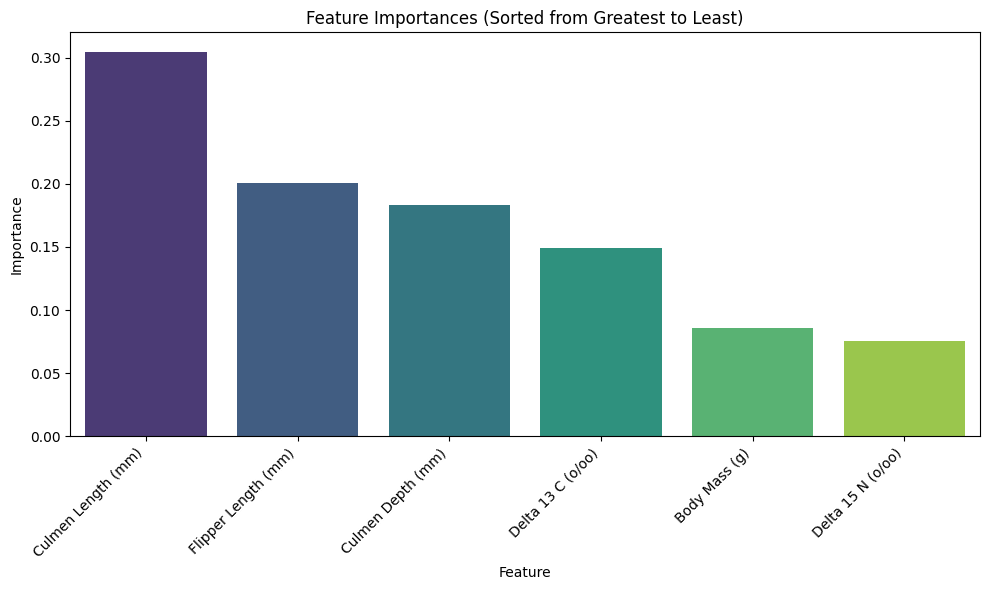

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Prepare data for classification
# We'll use the same features as for clustering, plus 'Species' as the target variable
features_clf = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)']
X_clf = df_ml[features_clf].copy()
y_clf = df_ml['Species'].copy()

# Handle any remaining NaN values in features (should already be handled but as a safeguard)
X_clf.fillna(X_clf.mean(), inplace=True)

# Encode target labels (Species) to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_clf)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Scale the features (important for many ML algorithms)
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
conf_mat = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(conf_mat, index=label_encoder.classes_, columns=label_encoder.classes_))

# Visualize Feature Importances
importances = model.feature_importances_
feature_names = X_clf.columns
forest_importances = pd.Series(importances, index=feature_names)

# Sort feature importances from greatest to least
forest_importances = forest_importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=forest_importances.index, y=forest_importances.values, ax=ax, palette='viridis')
ax.set_title("Feature Importances (Sorted from Greatest to Least)")
ax.set_ylabel("Importance")
ax.set_xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

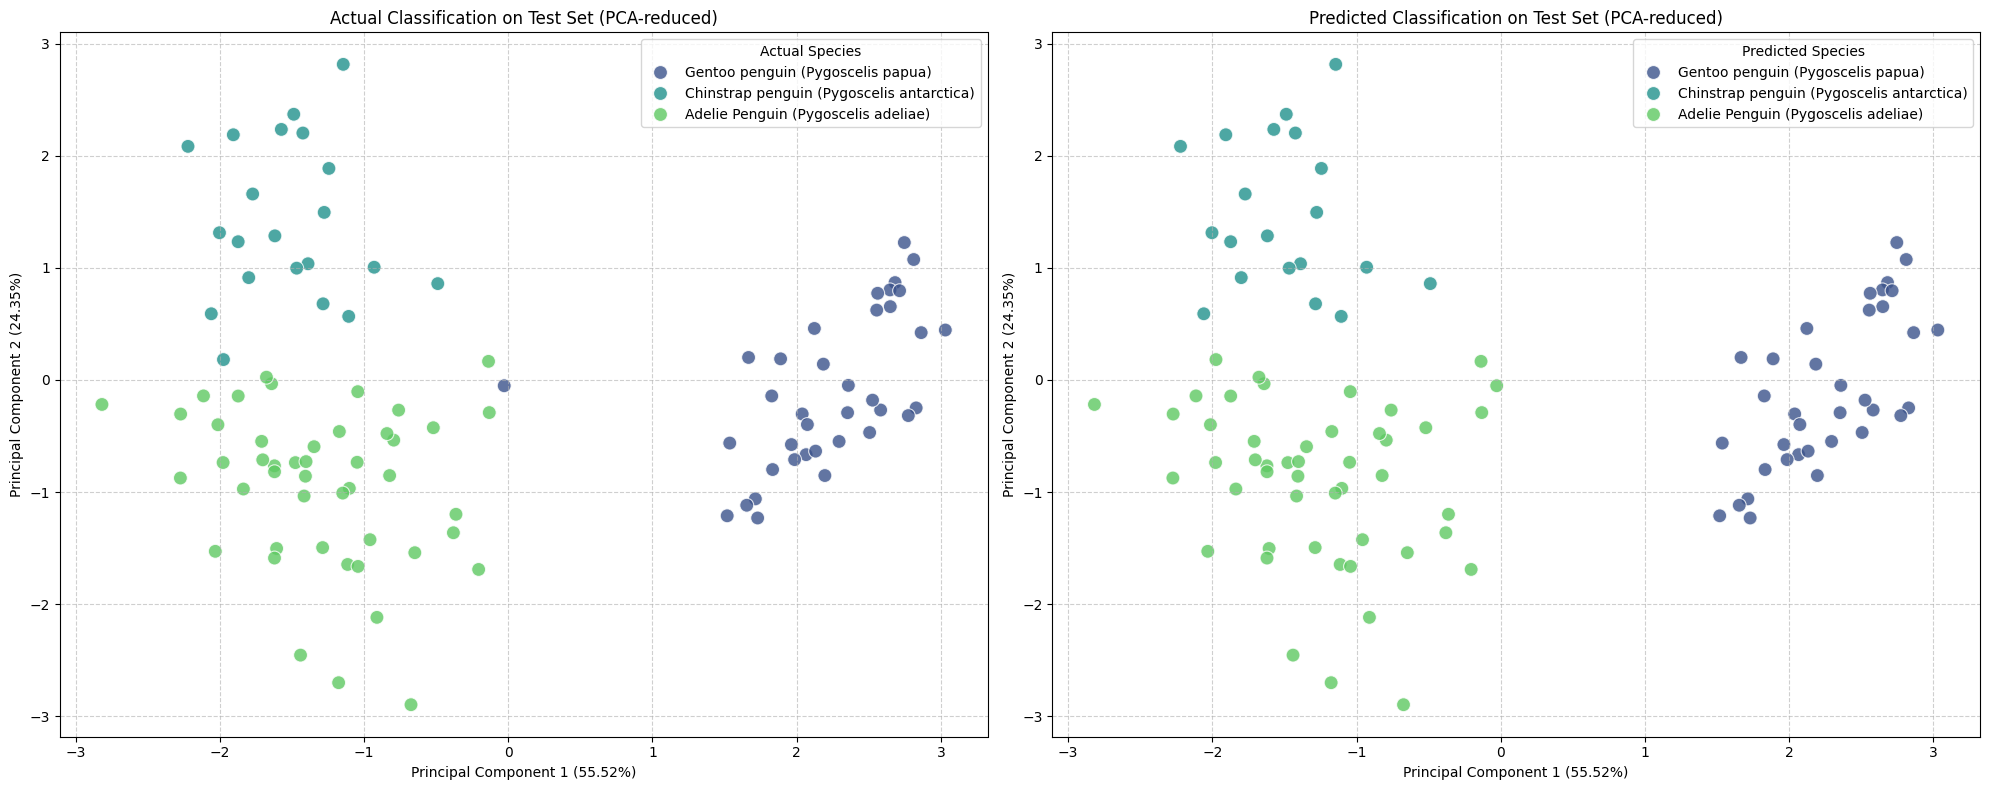

In [18]:
# Transform the test set features using the already fitted PCA
X_test_pca = pca.transform(X_test_scaled)

# Create a DataFrame for visualization of test set results
df_test_viz = pd.DataFrame(X_test_pca, columns=['PCA1', 'PCA2'])
df_test_viz['Actual Species'] = label_encoder.inverse_transform(y_test)
df_test_viz['Predicted Species'] = label_encoder.inverse_transform(y_pred)

# Create two subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot actual species
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Actual Species',
    palette='viridis',
    data=df_test_viz,
    s=100,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('Actual Classification on Test Set (PCA-reduced)')
axes[0].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot predicted species
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Predicted Species',
    palette='viridis',
    data=df_test_viz,
    s=100,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Predicted Classification on Test Set (PCA-reduced)')
axes[1].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()